# Machine Learning Optimization

### **All exercises will be using your chosen dataset**

## Step 1: Import your dataset using the tutorial from the slides

## Step 2: Install necessary libraries. We will be using scikit-learn again for week 4

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.svm import SVR, SVC
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve, CalibrationDisplay
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score, accuracy_score, classification_report, ConfusionMatrixDisplay

## Exercises

### Scikit-Learn Docs, ML Interpretability Book, and Demo for Reference

#### [Scikit-Learn](https://scikit-learn.org/stable/)
#### [ML Interpretability](https://christophm.github.io/interpretable-ml-book/)
#### [Demo](https://mdst-ai-in-healthcare.streamlit.app/)


Import your **preprocessed dataset** from week 3

In [15]:
# TODO: Load your dataset with pandas
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1.0,67.0,0,1,1,3,1,228.69,36.6,2,1
1,1.0,80.0,0,1,1,3,0,105.92,32.5,1,1
2,0.0,49.0,0,0,1,3,1,171.23,34.4,3,1
3,0.0,79.0,1,0,1,2,0,174.12,24.0,1,1
4,1.0,81.0,0,0,1,3,1,186.21,29.0,2,1


### Exercise 1: Cross Validation Evaluations

Rather than evaluating a model on a simple train-test split like we did in week 3, we can use cross validation to provide a more robust and accurate estimate of model performance. This method splits the data up into k subsets (k can be tuned) and is trained k times with k-1 subsets used for training and 1 subset for testing.

In [17]:
# TODO: Define the features and the target data
X = df.drop(columns=['stroke'])
y = df['stroke']

In [18]:
# TODO: initialize the model that you used in week 3. Either LinearRegression() or LogisticRegression()
cv_model = LogisticRegression()

Now we will calculate the cross validation scores using cross_val_score(). This outputs an array of k scores. These scores depict how well the model generalizes to new, unseen data. The defualt scoring for **regression** is **R^2** and the default for **classification** is **accuracy**.

In [19]:
# TODO: Calculate the cross validation score for this model on your data (use k=5)
scores = cross_val_score(cv_model, X, y, cv =5)

C:\Users\shirl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\shirl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the 

In [21]:
# TODO: Print the array of scores as well as the mean and standard deviation using np.mean() and np.std()
print(scores)
print(np.mean(scores))
print(np.std(scores))

[0.95621181 0.95621181 0.95519348 0.95718654 0.96024465]
0.9570096601207048
0.001735975712732029


How well does the model that you used generalize to unseen data? What factors might influence a model to not generalize well?

### Exercise 2: Regularization

**Regularization** is a technique that helps prevent a model from overfitting. Remember that overfitting is when a model learns noise in the training data and doesn't generalize to patterns. Underfitting on the other hand is when a model is too simple and doesn't understand the underlying structure in the data. Regularization adds a penalty term to a models cost function. A cost function calculates the models average errors between the predictions and the actual values. This penalty constrains the model from learning noise in the data and instead learns the patterns and encourages the model to generalize to unseen data.

**Lasso Regression (L1 Regularizer):** Adds the absolute value of the coefficients to the cost function. Good for selecting quality features and simplifying model coefficients

**Ridge Regression (L2 Regularizer):** Adds the squared magnitude of all the coefficients to the cost function. This is best used to deal with multicollinearity issues.

**ElasticNet Regression:** Combines both L1 and L2 regression to the cost function. Gives the best of both worlds.

If you used **linear regression:**

We will be using the regularizer **ElasticNet Regression**

In [22]:
# TODO: Initialize the ElasticNet model and use a small alpha to start to start (ElasticNet())
# Higher values of alpha result in better generalization but can cause underfitting and lower values can lead to overfitting
elastic_net = ElasticNet(alpha=0.001)

In [23]:
# TODO: using the model, run another cross validation evaluation
scores = cross_val_score(elastic_net, X, y, cv=5)

In [24]:
# TODO: Print the array of scores as well as the mean and standard deviation using np.mean() and np.std()
print(scores)
print(np.mean(scores))
print(np.std(scores))

[-0.27037516  0.          0.          0.          0.        ]
-0.05407503234152653
0.10815006468305306


Has the generalization of your model improved?

If you used **logistic regression:**

The Logistic Regression Model automatically uses L2 regularization by default. You will be comparing the difference between the cross validation score on the L2 regularizer and the ElasticNet regularizer.

In [32]:
# TODO: Initialize an L1 regularized logistic regression model using penalty="elasticnet"
elastic_net = LogisticRegression(penalty="elasticnet", solver="saga")

In [33]:
# TODO: using the model, run another cross validation evaluation
scores = cross_val_score(elastic_net, X, y, cv=5)

C:\Users\shirl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\shirl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\shirl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8

In [34]:
# TODO: Print the array of scores as well as the mean and standard deviation using np.mean() and np.std()
print(scores)
print(np.mean(scores))
print(np.std(scores))

[0.95723014 0.95417515 0.95723014 0.95514781 0.95922528]
0.9566017053133777
0.0017705923477258946


Has the generalization of your model improved?

Experiment with L1 and L2 Regularization and see which one gives the best cross validation scores.

### Exercise 3: Probability Calibration

Using predict_proba, we can calculate the probabilities of each class in classification. This can provide information in the confidence of a model for a particular class. However these probabilities don't reflect the empirical (real-world) probabilities of the classes that we are predicting. That is where probability calibration comes in. Probability calibration takes uncalibrated probabilities and maps them to more interpretable and accurate probabilities. For example, events with a predicted probability of 70% occur 70% of the time. The CalibratedClassifierCV in scikit-learn uses cross-validation to fit the model for optimizing the probabilities.

For the purposes of this exercise, we will be using a base classifier that has not been trained yet (CalibratedClassifierCV takes care of the training automatically)

In [35]:
# TODO: Define a LogisticRegression() Model optionally using the a custom regularizer
logistic_model = LogisticRegression()

There are different methods of mapping uncalibrated to calibrated probabilities.

**Sigmoid (Platt Scaling):** Fits a Logistic Regression Model; ideal for smaller datasets

**Isotonic Regression:** A more flexible approach that works better on larger (>1000) datasets

In [36]:
# TODO: Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [37]:
# TODO: Create a CalibratedClassifierCV() object with cv=5 and estimator=logistic_model. Choose your desired method
calibrated = CalibratedClassifierCV(estimator=logistic_model, method='isotonic', cv=5)

In [38]:
# TODO: Fit the calibrated model using the train data
calibrated.fit(X_train, y_train)

C:\Users\shirl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\shirl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the 

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LogisticRegression()
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.

In [39]:
# TODO: Next, fit the base logistic_model without any calibration
logistic_model.fit(X_train, y_train)

C:\Users\shirl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

NameError: name 'model_cal' is not defined

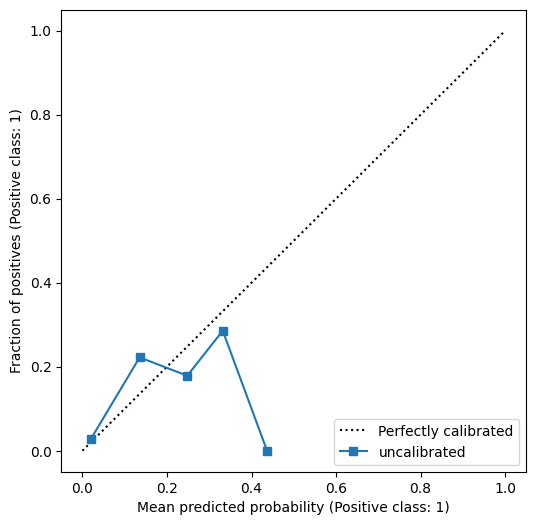

In [40]:
# TODO: Run this code block to graph the calibrated and uncalibrated probabilities for the model
fig, ax = plt.subplots(figsize=(6, 6))

# Default calibration curve (base model)
CalibrationDisplay.from_estimator(
    logistic_model,
    X_test, y_test,
    n_bins=10,
    strategy="uniform",
    name="uncalibrated",
    ax=ax
)

# Calibrated curve (calibrated model)
CalibrationDisplay.from_estimator(
    model_cal,
    X_test, y_test,
    n_bins=10,
    strategy="uniform",
    name="calibrated",
    ax=ax
)

ax.set_title("Calibration Plot")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Empirical Probability")
ax.legend(loc="best")
plt.show()

Did the probability calibration improve your models predicted probabilities? How well calibrated are your probabilities for the new model?

### Exercise 5: More Advanced Algorithms

So far, we have only been using logistic and linear regression which are very simple models that might not capture the underlying structure of the data you are working with. We will now be looking into other models the scikit-learn has to offer.

If your task is **regression**, ceate these models.

#### Random Forest Regressor:
Ensemble method that constucts many decision trees and averages the predictions for each tree

In [41]:
# TODO: Initialize the model (RandomForestRegressor())
rf = RandomForestRegressor()

In [42]:
# TODO: Calculate the cross validation score for this model on your data
scores = cross_val_score(rf, X, y, cv=5)

In [43]:
# TODO: Print the array of scores as well as the mean and standard deviation using np.mean() and np.std()
print(scores)
print(np.mean(scores))
print(np.std(scores))

[-0.27037516  0.          0.          0.          0.        ]
-0.05407503234152653
0.10815006468305306


#### Support Vector Regressor
Similar to Support Vector Machine, but for regression. Finds the optimal hyperplane to the given data with a defined tolerance or margin for error rather than minimizing the error for every single data point.

In [44]:
# TODO: Initialize the model (SVR())
svr = SVR()

In [45]:
# TODO: Calculate the cross validation score for this model on your data
scores = cross_val_score(svr, X, y, cv = 5)

In [46]:
# TODO: Print the array of scores as well as the mean and standard deviation using np.mean() and np.std()
print(scores)
print(np.mean(scores))
print(np.std(scores))

[-0.27037516  0.          0.          0.          0.        ]
-0.05407503234152653
0.10815006468305306


If your task is **classification**, ceate these models.

#### Random Forest Classifier
Similar to the RandomForestRegressor, but instead of taking th average of the decision trees, it takes the most likely class given the class outputs of the individual trees.

In [47]:
# TODO: Initialize the model (RandomForestClassifier())
rfc = RandomForestClassifier()

In [48]:
# TODO: Calculate the cross validation score for this model on your data
scores = cross_val_score(rfc, X, y, cv=5)

In [49]:
# TODO: Print the array of scores as well as the mean and standard deviation using np.mean() and np.std()
print(scores)
print(np.mean(scores))
print(np.std(scores))

[0.95519348 0.95723014 0.95621181 0.95616718 0.95820591]
0.9566017053133778
0.0010288183741065243


#### Support Vector Machine:
Finds an optimal hyperplane that maximizes the distance between the classes that the model is predicting

In [50]:
# TODO: Initialize the model (SVC())
svc = SVC()

In [51]:
# TODO: Calculate the cross validation score for this model on your data
scores = cross_val_score(svc, X, y, cv=5)

In [52]:
# TODO: Print the array of scores as well as the mean and standard deviation using np.mean() and np.std()
print(scores)
print(np.mean(scores))
print(np.std(scores))

[0.95723014 0.95723014 0.95723014 0.95718654 0.95820591]
0.957416576875087
0.00039502878069811435


Which model had the best overall cross-validation score?

### Exercise 6: Further Exploration

Keep experimenting with different models, regularizers, etc...